In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
# read data
path = r"C:\Users\mejse\Documents\uni\4. semester\Dataprojekt\projekt\Federated-dental-risk-vol2\data\processed\A\global_test_set_non-iid.csv"
path_big = r'C:\Users\mejse\Documents\uni\4. semester\Dataprojekt\projekt\Federated-dental-risk-vol2\data\raw\synthetic_dataset_A_non-iid.csv'
df = pd.read_csv(path_big)
df = df[:20000]

In [144]:
# Add new column 'Complication', 1 if one or more of the 4 complications happen 0 otherwise
df["Complication"] = ((df["Risk_SecondaryInfection"] == 1) | (df["Risk_NerveDysesthesia"]==1) | (df["Risk_Bleeding"] == 1) | (df["Risk_Category_AlveolarOsteitis"]==1)).astype(int)

In [145]:
# This is a list of all the colums
cols = df.columns.tolist()
print(cols)

['Client', 'Patient', 'Age', 'Sex', 'Pain', 'Swelling', 'Trismus', 'Pericoronitis', 'Caries_Wisdom', 'Caries_Adjacent', 'Periodontal_Status', 'Root_Development', 'Tooth_Mobility', 'Tooth_Angulation', 'Impaction_Depth', 'Proximity_Nerve', 'Root_Count', 'Root_Curvature', 'Bone_Density', 'Cyst', 'Diabetes', 'Osteoporosis', 'Clotting_Disorder', 'Smoking', 'Bisphosphonates', 'Prev_Extraction_Issue', 'Surgical_Extraction_Type', 'Score_1', 'Score_2', 'Score_3', 'Prob_1', 'Prob_2', 'Prob_3', 'Removal_Indicated', 'Removal_Prob', 'Risk_AlveolarOsteitis', 'Risk_AlveolarOsteitis_Prob', 'Risk_SecondaryInfection', 'Risk_SecondaryInfection_Prob', 'Risk_NerveDysesthesia', 'Risk_NerveDysesthesia_Prob', 'Risk_Bleeding', 'Risk_Bleeding_Prob', 'Risk_Category_AlveolarOsteitis', 'Risk_Category_SecondaryInfection', 'Risk_Category_NerveDysesthesia', 'Risk_Category_Bleeding', 'Risk_Category_Composite', 'Complication']


# Manuelt (virker ikke...)

In [131]:
# Create training data, using only patient observations 
train_cols = ['Client', 'Patient', 'Age', 'Sex', 'Pain', 'Swelling', 'Trismus', \
              'Pericoronitis', 'Caries_Wisdom', 'Caries_Adjacent', 'Periodontal_Status', \
                'Root_Development', 'Tooth_Mobility', 'Tooth_Angulation', 'Impaction_Depth', \
                    'Proximity_Nerve', 'Root_Count', 'Root_Curvature', 'Bone_Density', 'Cyst', \
                        'Diabetes', 'Osteoporosis', 'Clotting_Disorder', 'Smoking', \
                            'Bisphosphonates', 'Prev_Extraction_Issue', 'Surgical_Extraction_Type']

# 'Score_1', 'Score_2', 'Score_3', 'Prob_1', 'Prob_2', 'Prob_3', 'Removal_Indicated', 'Removal_Prob' 
# Skal de her med ???
train_df = df[train_cols]
train_data = np.array(train_df)[:,1:] # without the client
client = np.array(train_df)[:,0] # the clients
targets = np.array(df['Complication']) # targets
targets = targets.reshape((-1,1))
N, D = train_data.shape

In [132]:
train_data[0].reshape((-1,1)).shape

(26, 1)

In [133]:
np.random.seed(42)
w0 = 2 * np.random.random((D, 1)) -1
w0.shape

(26, 1)

In [134]:
def y(w, x):
    a = (w.T @ x)[0,0]  # make sure a is a scalar
    if a >= 0:
        y_val = 1 / (1 + np.exp(-a))
    else:
        exp_a = np.exp(a)
        y_val = exp_a / (1 + exp_a)
    return np.clip(y_val, 1e-15, 1-1e-15)

def error_func(w,X,t):
    N = len(X)
    sum_ = 0
    for n in range(N):
        xn = X[n,:].reshape((-1,1))
        yn = y(w,xn)
        tn = t[n]
        sum_ += (tn * np.log(yn) + (1-tn) * (np.log(1-yn)))
    return -sum_[0]


def gradient(w,X,t):
    N = len(X)
    sum_ = 0
    for n in range(N):
        xn = X[n,:].reshape((-1,1))
        yn = y(w,xn)
        tn = t[n]
        sum_ += (yn - tn)*xn
    return sum_

def update(w,X,t):
    N = len(X)
    R = np.zeros((N,N))
    R_diag = []
    for n in range(N):
        xn = X[n,:].reshape((-1,1))
        yn = y(w,xn)
        R_diag.append(yn*(1-yn))
    R += np.diag(R_diag)
    H = X.T @ R @ X

    lambda_ = 1e-4  # small damping factor to mahe H inversible
    H_reg = H + lambda_ * np.eye(H.shape[0])
    w_new = w - np.linalg.inv(H_reg) @ gradient(w,X,t)

    return w_new


In [135]:
def logistic_learn(X,t):
    # dimensions
    N,D = X.shape

    # initialize weights randomly between -1 and 1
    np.random.seed(42)
    w0 = 2 * np.random.random((D, 1)) -1

    iter_vs_error = []

    for i in range(100):
        error = error_func(w0,X,t)
        w_new = update(w0,X,t)
        w0 = w_new
        iter_vs_error.append([i,error])
    
    return iter_vs_error, w_new



res = logistic_learn(train_data,targets)

MemoryError: Unable to allocate 16.5 GiB for an array with shape (47000, 47000) and data type float64

[40366.71982474 61929.43896473 41377.4541211  41377.4541211
 62240.3159382  41377.4541211  62240.3159382  41377.4541211
 41377.4541211  62240.3159382  41377.4541211  62240.3159382
 41377.4541211  41377.4541211  62240.3159382  41377.4541211
 62240.3159382  41377.4541211  41377.4541211  62240.3159382
 41377.4541211  62240.3159382  41377.4541211  41377.4541211
 62240.3159382  41377.4541211  62240.3159382  41377.4541211
 61929.43496675 41377.4541211  41377.4541211  62240.3159382
 41377.4541211  62240.314339   41377.4541211  41377.4541211
 62240.3159382  41377.4541211  62240.3151386  41377.4541211
 41377.4541211  62240.3159382  41377.4541211  62205.77636221
 41377.4541211  41377.4541211  62240.3159382  41377.4541211
 62205.77636221 41377.4541211  41377.4541211  62240.3159382
 41377.4541211  62205.77636221 41377.4541211  61929.43576634
 41377.4541211  41377.4541211  62205.77636221 41377.4541211
 62343.93066819 41377.4541211  41377.4541211  62205.77636221
 41377.4541211  62240.314339   41377.

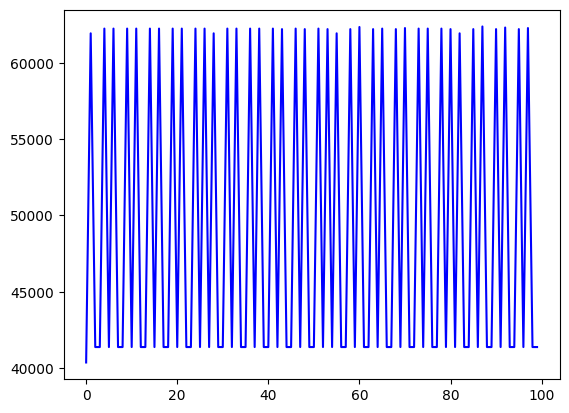

In [ ]:
fig, ax = plt.subplots()
res_0 = np.array(res[0])
print(res_0[:,1])
ax.plot(res_0[:,0],res_0[:,1],'b-')

In [ ]:
def per_client_models_aggregated(X,t,client):
    D = len(X[0])
    w = np.zeros((D,1))
    for cli in range(1,11):
        X_cli = X[client==cli]
        t_cli = t[client==cli]
        N_cli,_ = X_cli.shape
        cli_res = logistic_learn(X_cli,t_cli)
        w += cli_res[1]/N_cli # wheighted by number of patients

    error = error_func(w,X,t)

    return error, w 

res_local = per_client_models_aggregated(train_data,targets,client)

In [ ]:
res_local

(np.float64(41377.45412110345),
 array([[-4.38637202e+07],
        [-4.48841859e+06],
        [-3.95564497e+04],
        [ 2.53158422e+05],
        [ 6.61964450e+04],
        [ 3.01224299e+05],
        [-6.31587696e+03],
        [-4.19382927e+04],
        [ 1.61367519e+05],
        [-1.60493413e+05],
        [ 1.93273156e+05],
        [-1.90713816e+05],
        [-7.34919583e+05],
        [-3.37301946e+05],
        [ 2.18066634e+05],
        [ 3.11570086e+04],
        [-1.23989328e+05],
        [-3.48889091e+05],
        [ 8.03600770e+04],
        [ 9.58159730e+04],
        [ 7.31107918e+03],
        [-8.15421487e+04],
        [ 2.07927763e+05],
        [-4.76525948e+03],
        [ 1.36146560e+04],
        [ 1.04049020e+05]]))

In [ ]:

yn = [y(res_local[1],train_data[n,:].reshape((-1,1))) for n in range(N)]
yn

[np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),
 np.float64(1e-15),


# med Sklearn (uden plots)

In [ ]:
# Add new column 'Complication', 1 if one or more of the 4 complications happen 0 otherwise
df["Complication"] = ((df["Risk_SecondaryInfection"] == 1) | (df["Risk_NerveDysesthesia"]==1) | (df["Risk_Bleeding"] == 1) | (df["Risk_Category_AlveolarOsteitis"]==1)).astype(int)

In [ ]:
# choose features and target
features = df.columns.tolist()[1:27]
X = df[features]
y = df['Complication']

# Split into training and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=16))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


# import the metrics class
#from sklearn import metrics

#cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
#cnf_matrix

from sklearn.metrics import classification_report
target_names = ['no complication', 'complication']
print(classification_report(y_test, y_pred, target_names=target_names))


                 precision    recall  f1-score   support

no complication       0.63      0.89      0.74       443
   complication       0.60      0.24      0.34       307

       accuracy                           0.62       750
      macro avg       0.62      0.57      0.54       750
   weighted avg       0.62      0.62      0.58       750



# Centralized

In [146]:
def prepare_data(df,begin = 1, end = 27, cli = False):
    # Prepare data
    features = df.columns.tolist()[begin:end]
    X = df[features].values
    y = df['Complication'].values
    # Scale data (normalization)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    if cli:
        X = np.c_[df['Client'],np.ones(X.shape[0]), X]
    else:
        X = np.c_[np.ones(X.shape[0]), X]

    # Split into training and test set
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)
    
    return X_train, X_test, y_train, y_test

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Loss function (cross entropy)
def compute_loss(y, p):
    epsilon = 1e-15  # avoid log(0)
    p = np.clip(p, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def train_centralized(X_train, y_train, n_iter = 10, alpha = 0.5 ):

    # Initialize weights
    np.random.seed(16)
    w = np.zeros(X_train.shape[1])

    loss_history = []

    for _ in range(n_iter):
        z = X_train @ w
        p = sigmoid(z)
        
        loss = compute_loss(y_train, p)
        loss_history.append(loss)
        
        n = len(y_train)
        
        # Gradient
        gradient = (X_train.T @ (p - y_train)) / n
        
        # Hessian
        W = np.diag(p * (1 - p))
        H = (X_train.T @ W @ X_train) / n
        
        # Stabilize Hessian
        H += 1e-5 * np.eye(H.shape[0])
        
        # Newton step (stable)
        w -= alpha * np.linalg.solve(H, gradient)
        
        

    # Plot loss curve
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Log Loss")
    plt.title("Training Loss over Iterations")
    plt.show()

    return w

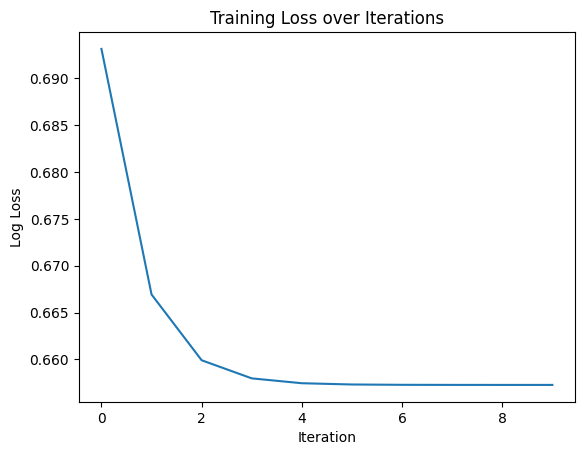

In [147]:
X_train, X_test, y_train, y_test = prepare_data(df)
w = train_centralized(X_train,y_train)

In [148]:
def predict_and_evaluate(X_test, y_test, w, threshold = 0.3):
    z_test = X_test @ w
    p_test = sigmoid(z_test)
    y_pred = (p_test >= threshold).astype(int)

    from sklearn.metrics import classification_report

    target_names = ['no complication', 'complication']
    print(classification_report(y_test, y_pred, target_names=target_names))

    return y_pred

In [149]:
y_pred = predict_and_evaluate(X_test, y_test, w)

                 precision    recall  f1-score   support

no complication       0.74      0.19      0.30      3073
   complication       0.41      0.89      0.56      1927

       accuracy                           0.46      5000
      macro avg       0.57      0.54      0.43      5000
   weighted avg       0.61      0.46      0.40      5000



# local

In [150]:
X_train, X_test, y_train, y_test = prepare_data(df, cli=True)
np.unique(X_train[:,0])

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [151]:
def train_local(X_train, y_train, n_iter = 10, alpha = 0.5 ):

    client = X_train[:,0]
    X_train = X_train[:,1:]
    

    w = []
    loss_history = []

    for c in np.unique(client):
        X_train_c = X_train[client == c]
        y_train_c = y_train[client == c]
        
        # Initialize weights
        np.random.seed(16)
        c_w = np.zeros(X_train_c.shape[1])

        c_loss_history = []

        for _ in range(n_iter):
            z = X_train_c @ c_w
            p = sigmoid(z)
            
            loss = compute_loss(y_train_c, p)
            c_loss_history.append(loss)
            
            n = len(y_train_c)
            
            # Gradient
            gradient = (X_train_c.T @ (p - y_train_c)) / n
            
            # Hessian
            W = np.diag(p * (1 - p))
            H = (X_train_c.T @ W @ X_train_c) / n
            
            # Stabilize Hessian
            H += 1e-5 * np.eye(H.shape[0])
            
            # Newton step (stable)
            c_w -= alpha * np.linalg.solve(H, gradient)
        
        w.append(c_w)
        loss_history.append(c_loss_history)

    w_all = np.mean(w, axis=0)

    # Plot loss curves
    for i in range(10):
        plt.plot(loss_history[i], label=f'client = {i+1}')
    plt.legend()
    plt.xlabel("Iteration")
    plt.ylabel("Log Loss")
    plt.title("Training Loss over Iterations")
    plt.show()

    return w_all

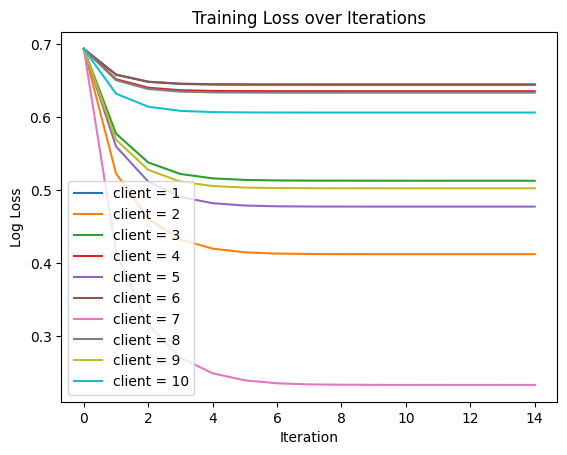

In [152]:
w = train_local(X_train, y_train, n_iter=15)

In [153]:
w

array([ 0.09669201,  0.0262832 ,  0.1208456 , -0.01299415,  0.04822586,
        0.06333633,  0.04512641,  0.08128971,  0.0065412 ,  0.01330812,
        0.03768094,  0.01447772,  0.0117056 , -0.02349211,  0.25650417,
        0.7655004 , -0.00379529, -0.03345116, -0.04253632,  0.04206251,
       -0.02768928, -0.09998609, -0.19676446, -0.05711573,  0.00892612,
        0.02895645,  0.14612548])

In [154]:
y_pred = predict_and_evaluate(X_test[:,1:],y_test,w)

                 precision    recall  f1-score   support

no complication       0.85      0.30      0.44      3073
   complication       0.45      0.91      0.60      1927

       accuracy                           0.54      5000
      macro avg       0.65      0.61      0.52      5000
   weighted avg       0.69      0.54      0.50      5000



# Federated

## first attempt... (virker ikke)

In [ ]:
X_train, X_test, y_train, y_test = prepare_data(df, cli=True)

def sigmoid(z):
    z = np.clip(z, -500, 500)  # prevent overflow
    return 1 / (1 + np.exp(-z))

def train_federated(X_train, y_train, n_rounds = 10, alpha = 0.1 ):

    client = X_train[:,0]
    X_train = X_train[:,1:]
    

    loss_history =[]

    w = np.zeros(X_train.shape[1])
    
    for r in range(n_rounds):     

        w_list = []

        for c in np.unique(client):
            c_w = w[:]

            X_train_c = X_train[client == c]
            y_train_c = y_train[client == c]
            
            z = X_train_c @ c_w
            p = sigmoid(z)
            
            n = len(y_train_c)
            
            # Gradient
            gradient = (X_train_c.T @ (p - y_train_c)) / n
            
            # Hessian
            W = np.diag(p * (1 - p))
            H = (X_train_c.T @ W @ X_train_c) / n
            
            # Stabilize Hessian
            H += 1e-5 * np.eye(H.shape[0])
            
            # Newton step (stable)
            c_w -= alpha * np.linalg.solve(H, gradient)
            w_list.append(c_w)

        # some aggregation...    
        w = np.mean(w_list,axis=0)
        
        z = X_train @ w
        p = sigmoid(z)
            
        loss = compute_loss(y_train, p)
        loss_history.append(loss)

    # Plot loss curves
    plt.plot(loss_history)
    plt.xlabel("Round")
    plt.ylabel("Log Loss")
    plt.title("Training Loss over Rounds")
    plt.show()

    return w

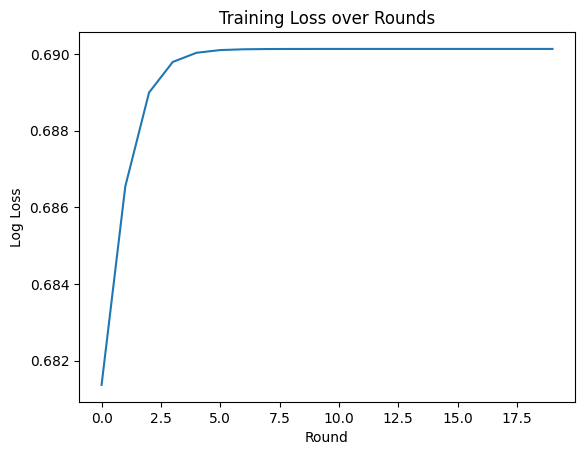

array([-0.01466005,  0.10303297, -0.00482891, -0.05708167, -0.08240196,
        0.02088284, -0.07815526,  0.09726567,  0.10922666, -0.03402387,
        0.00281287, -0.08468556,  0.00382319,  0.04031859,  0.17376215,
        0.54342094, -0.08491146, -0.04285421, -0.03530052,  0.02987595,
       -0.01401838,  0.07103107, -0.00996575,  0.060532  , -0.07165603,
        0.00601336,  0.06859391])

In [ ]:
train_federated(X_train,y_train,n_rounds=20)

## Second attempt :-)

In [155]:
def local_train(X, y, w, lr=0.01, local_epochs=5):
    w_local = w.copy()
    
    for _ in range(local_epochs):
        z = X @ w_local
        p = sigmoid(z)
        
        gradient = (X.T @ (p - y)) / len(y)
        
        w_local -= lr * gradient
    
    return w_local

def train_federated_FedAvg(X_train, y_train, n_rounds=10, lr=0.01, local_epochs=5, cli=True):
    
    client = X_train[:, 0]
    X_train = X_train[:, 1:]
    
    w = np.zeros(X_train.shape[1])
    loss_history = []

    for r in range(n_rounds):
        
        w_list = []
        n_samples = []

        # Train per client
        for c in np.unique(client):
            X_c = X_train[client == c]
            y_c = y_train[client == c]

            w_c = local_train(X_c, y_c, w, lr, local_epochs)

            w_list.append(w_c)
            n_samples.append(len(y_c))

        # Weighted averaging
        total_samples = sum(n_samples)

        w = sum(
            (n / total_samples) * w_c
            for w_c, n in zip(w_list, n_samples)
        )

        # Compute global loss
        z = X_train @ w
        p = sigmoid(z)
        loss = compute_loss(y_train, p)
        loss_history.append(loss)


    plt.plot(loss_history)
    plt.xlabel("Round")
    plt.ylabel("Log Loss")
    plt.title("Training Loss over Rounds")
    plt.show()
    
    return w


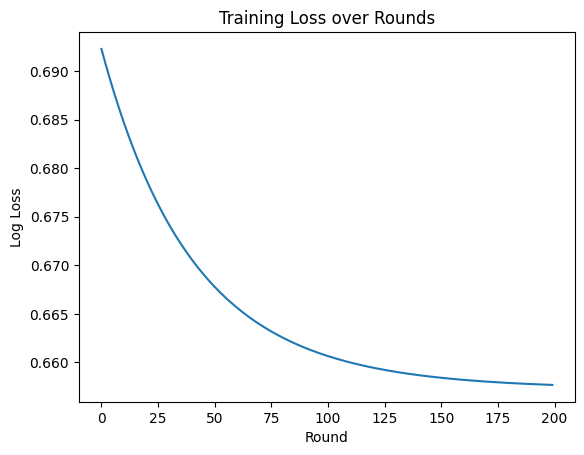

In [156]:
w = train_federated_FedAvg(X_train,y_train,n_rounds=200)

In [157]:
y_pred = predict_and_evaluate(X_test[:,1:],y_test,w)

                 precision    recall  f1-score   support

no complication       0.81      0.12      0.20      3073
   complication       0.40      0.96      0.57      1927

       accuracy                           0.44      5000
      macro avg       0.61      0.54      0.39      5000
   weighted avg       0.65      0.44      0.34      5000



# Fire modeller

In [158]:
def prepare_data_for_four_models(df,begin = 1, end = 27, cli = False, target = 'Complication'):
    # Prepare data
    features = df.columns.tolist()[begin:end]
    X = df[features].values
    y = df[target].values
    # Scale data (normalization)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    if cli:
        X = np.c_[df['Client'],np.ones(X.shape[0]), X]
    else:
        X = np.c_[np.ones(X.shape[0]), X]

    # Split into training and test set
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)
    
    return X_train, X_test, y_train, y_test

In [159]:
complications = ['Risk_NerveDysesthesia','Risk_Bleeding',\
                 'Risk_AlveolarOsteitis','Risk_SecondaryInfection']

In [160]:
def fed_train_all_complications(df,complications):
    weights = []
    predictions = []
    true_vals = []
    for c in complications:
        print(f'For complication {c}:')
        X_train, X_test, y_train, y_test = prepare_data_for_four_models(df, cli=True, target=c)
        true_vals.append(y_test)
        w = train_federated_FedAvg(X_train,y_train,n_rounds=300)
        weights.append(w)
        y_pred = predict_and_evaluate(X_test[:,1:],y_test,w, threshold=0.1)
        predictions.append(y_pred)
    return weights, predictions, true_vals
        


For complication Risk_NerveDysesthesia:


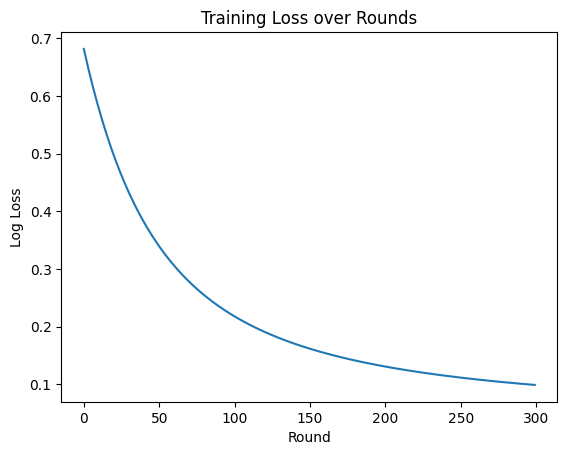

c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

                 precision    recall  f1-score   support

no complication       0.99      1.00      1.00      4967
   complication       0.00      0.00      0.00        33

       accuracy                           0.99      5000
      macro avg       0.50      0.50      0.50      5000
   weighted avg       0.99      0.99      0.99      5000

For complication Risk_Bleeding:


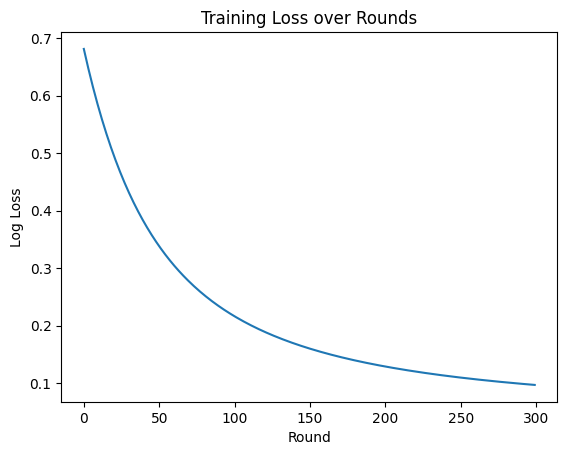

c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

                 precision    recall  f1-score   support

no complication       0.99      1.00      1.00      4967
   complication       0.00      0.00      0.00        33

       accuracy                           0.99      5000
      macro avg       0.50      0.50      0.50      5000
   weighted avg       0.99      0.99      0.99      5000

For complication Risk_AlveolarOsteitis:


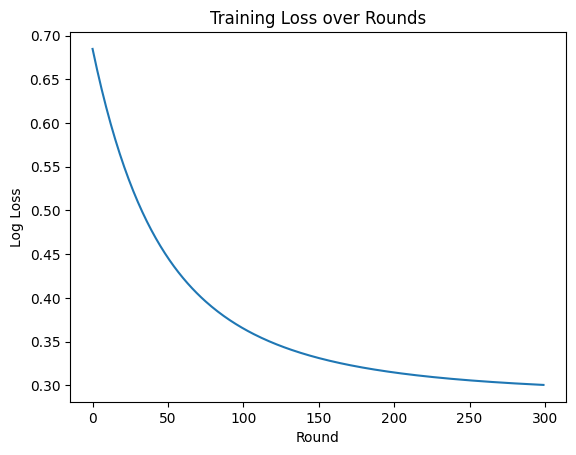

                 precision    recall  f1-score   support

no complication       0.97      0.28      0.44      4553
   complication       0.11      0.91      0.20       447

       accuracy                           0.34      5000
      macro avg       0.54      0.59      0.32      5000
   weighted avg       0.89      0.34      0.42      5000

For complication Risk_SecondaryInfection:


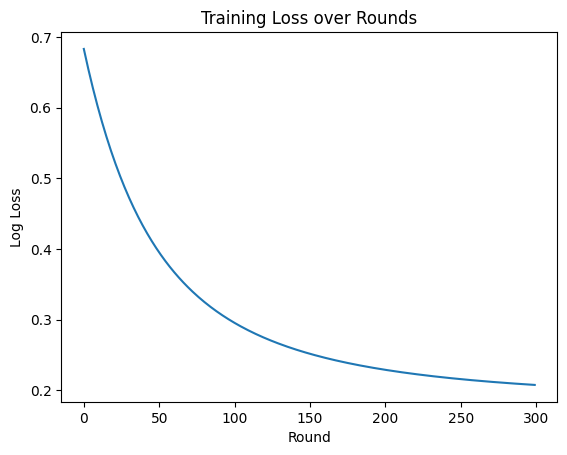

                 precision    recall  f1-score   support

no complication       0.97      0.55      0.70      4750
   complication       0.07      0.69      0.14       250

       accuracy                           0.56      5000
      macro avg       0.52      0.62      0.42      5000
   weighted avg       0.93      0.56      0.68      5000



In [161]:
weights, predictions, true_vals = fed_train_all_complications(df,complications)

In [162]:
weights

[array([-2.52421315e+00, -1.63046635e-05,  2.92210342e-02, -1.09707260e-03,
         6.97948298e-03, -4.81256176e-03, -3.09851143e-03,  4.80073737e-03,
        -1.59121011e-03,  5.48791336e-03,  6.56341929e-04, -1.02758187e-02,
        -1.93854697e-03, -4.61811565e-03,  2.33776141e-02,  5.08666393e-02,
         6.27336142e-04,  7.36638496e-04, -1.95951770e-03,  1.36746531e-02,
        -6.05130151e-03, -9.27719415e-03, -3.92572501e-03, -2.07891588e-03,
        -1.48750980e-03,  8.03422449e-03, -3.67350155e-02]),
 array([-2.53021056e+00, -1.21404198e-03,  2.55943232e-02, -8.77205233e-04,
        -1.18935473e-02, -4.45147409e-04,  5.15174618e-03,  4.72437496e-03,
        -6.43033743e-03,  3.66683314e-03,  1.13673079e-03, -1.18814267e-02,
        -1.34267367e-03, -1.14680237e-02,  2.30101084e-02,  1.63967734e-02,
         2.54230523e-03,  1.14461344e-02,  8.83894496e-03,  5.08386105e-03,
        -1.07602513e-02, -1.02078742e-02,  8.63446059e-03,  1.02097089e-02,
         6.86560758e-03,  6

In [163]:
def plot_magnitude(coefs, variable_names, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    magnitudes = np.abs(coefs)
    
    ax.bar(range(len(coefs)), magnitudes)
    
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(variable_names, rotation=90)
    
    ax.set_title(title)
    ax.set_xlabel("Variables")
    ax.set_ylabel("|Coefficient|")
    
    plt.tight_layout()
    plt.show()

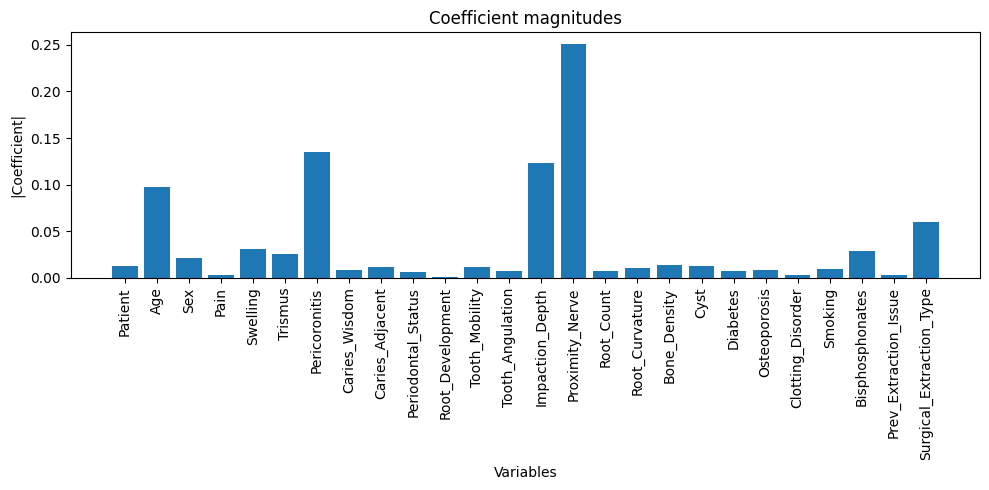

In [199]:
plot_magnitude(weights[2][1:], cols[1:27], title=f"Coefficient magnitudes")

## categories

In [165]:
df.columns

Index(['Client', 'Patient', 'Age', 'Sex', 'Pain', 'Swelling', 'Trismus',
       'Pericoronitis', 'Caries_Wisdom', 'Caries_Adjacent',
       'Periodontal_Status', 'Root_Development', 'Tooth_Mobility',
       'Tooth_Angulation', 'Impaction_Depth', 'Proximity_Nerve', 'Root_Count',
       'Root_Curvature', 'Bone_Density', 'Cyst', 'Diabetes', 'Osteoporosis',
       'Clotting_Disorder', 'Smoking', 'Bisphosphonates',
       'Prev_Extraction_Issue', 'Surgical_Extraction_Type', 'Score_1',
       'Score_2', 'Score_3', 'Prob_1', 'Prob_2', 'Prob_3', 'Removal_Indicated',
       'Removal_Prob', 'Risk_AlveolarOsteitis', 'Risk_AlveolarOsteitis_Prob',
       'Risk_SecondaryInfection', 'Risk_SecondaryInfection_Prob',
       'Risk_NerveDysesthesia', 'Risk_NerveDysesthesia_Prob', 'Risk_Bleeding',
       'Risk_Bleeding_Prob', 'Risk_Category_AlveolarOsteitis',
       'Risk_Category_SecondaryInfection', 'Risk_Category_NerveDysesthesia',
       'Risk_Category_Bleeding', 'Risk_Category_Composite', 'Complicatio

In [183]:
def prepare_data_for_four_models_category(df,begin = 1, end = 49, cli = False):
                                          
    # Prepare data
    features = df.columns.tolist()[begin:end]
    X = df[features].values

    # Scale data (normalization)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X[1:27] = scaler.fit_transform(X[1:27])
    if cli:
        X = np.c_[df['Client'],np.ones(X.shape[0]), X]
    else:
        X = np.c_[np.ones(X.shape[0]), X]

    # Split into training and test set
    from sklearn.model_selection import train_test_split
    X_train, X_test = train_test_split(X, test_size=0.25, random_state=16)
    
    return X_train, X_test

In [200]:
y_hat = sigmoid(X_train[:,1:] @ weights[2])

In [185]:
def assign_tertiles(y_hat):
    """
    Deler y_hat i 3 grupper baseret på 1/3 og 2/3 kvantiler.
    Returnerer både gruppe-labels og grænserne.
    """
    q1 = np.quantile(y_hat, 1/3)
    q2 = np.quantile(y_hat, 2/3)

    groups = np.where(
        y_hat <= q1, 0,
        np.where(y_hat <= q2, 1, 2)
    )

    return groups, q1, q2

In [201]:
preds,q1,q2 = assign_tertiles(y_hat)

In [202]:
import numpy as np

def f1_macro_score(y_true, y_pred, classes=[0,1,2]):
    f1_scores = []

    for c in classes:
        # True positives, false positives, false negatives
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        # Precision og recall (undgå division med 0)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        # F1 score for klassen
        if precision + recall > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0

        f1_scores.append(f1)

    # Macro = gennemsnit over klasser
    return np.mean(f1_scores)

In [203]:
train, test = prepare_data_for_four_models_category(df, cli = True)
y_true = train[:,-6]
f1_macro_score(y_true, preds)

np.float64(0.6679552486206571)

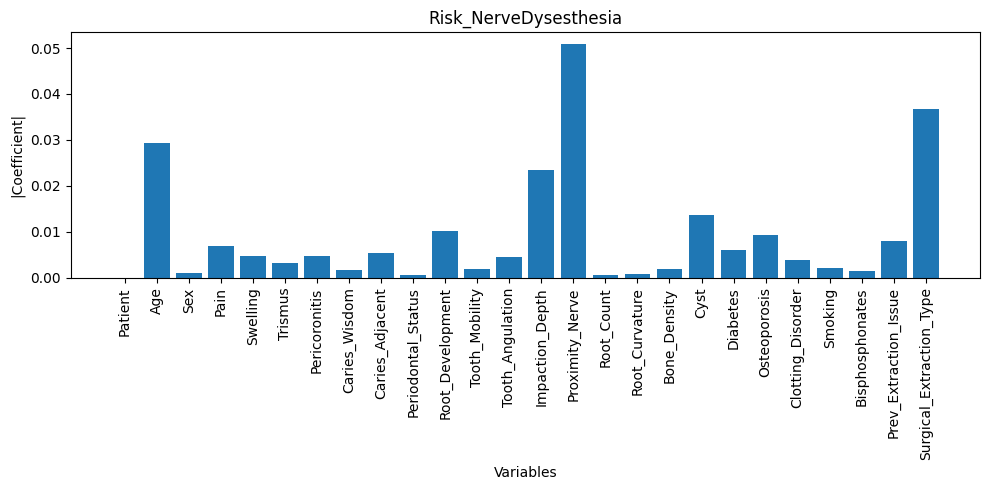

0.5786006530342137


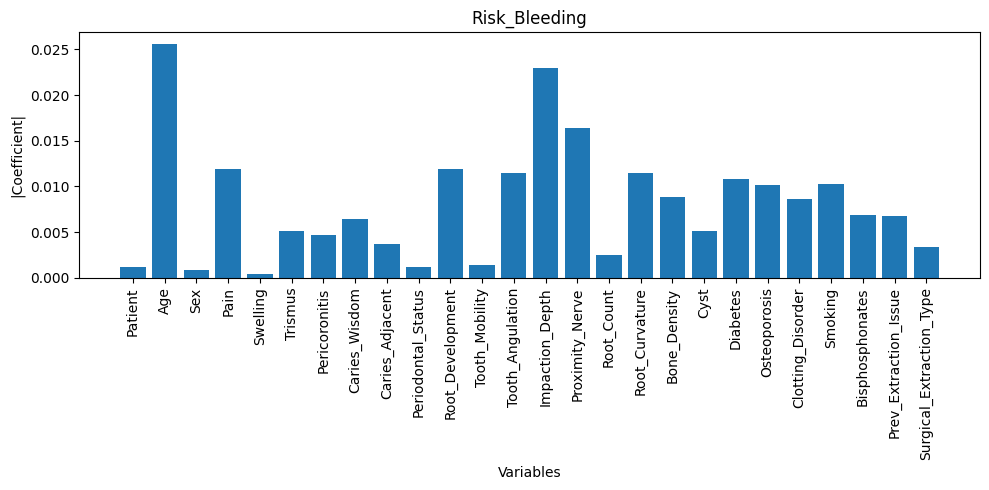

0.539691854855089


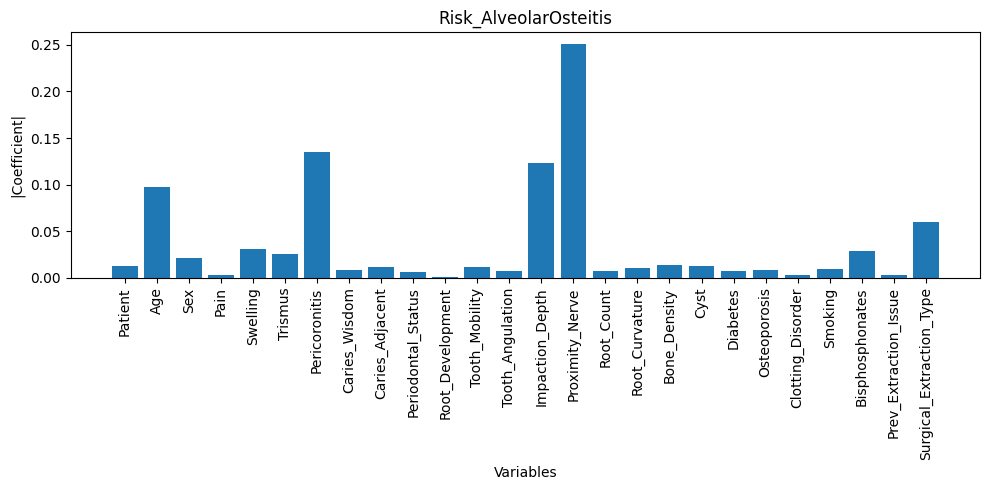

0.6679552486206571


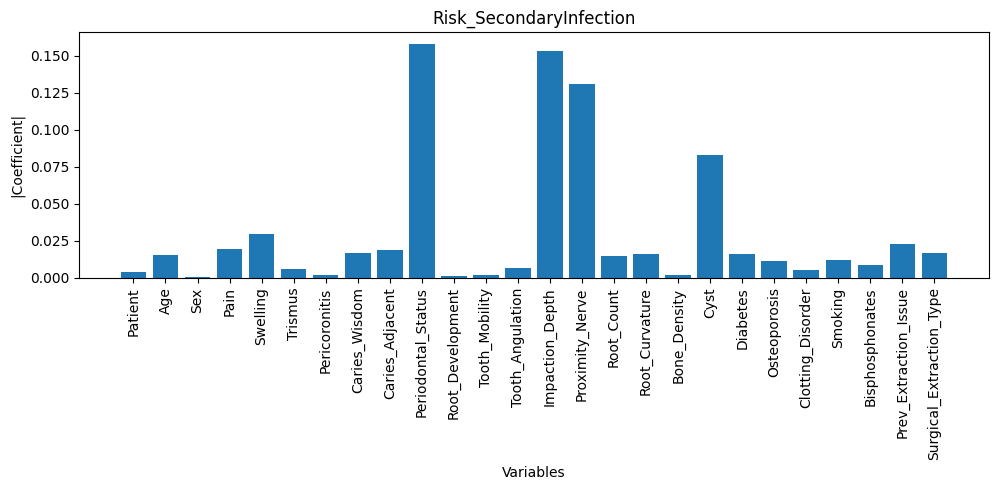

0.5578147073281117


In [207]:
loc = [-4,-3,-6,-5]
for i in range(4):
    plot_magnitude(weights[i][1:], cols[1:27], title=complications[i])
    y_hat = sigmoid(X_train[:,1:] @ weights[i])
    train, test = prepare_data_for_four_models_category(df, cli = True)
    y_true = train[:,loc[i]]
    f1 = f1_macro_score(y_true, preds)
    print(f1)

# Bigger dataset

In [ ]:
path = r'C:\Users\mejse\Documents\uni\4. semester\Dataprojekt\projekt\Federated-dental-risk-vol2\data\raw\synthetic_dataset_A_non-iid.csv'
df_big = pd.read_csv(path)
df_big

,Client,Patient,Age,Sex,Pain,Swelling,Trismus,Pericoronitis,Caries_Wisdom,Caries_Adjacent,...,Risk_SecondaryInfection_Prob,Risk_NerveDysesthesia,Risk_NerveDysesthesia_Prob,Risk_Bleeding,Risk_Bleeding_Prob,Risk_Category_AlveolarOsteitis,Risk_Category_SecondaryInfection,Risk_Category_NerveDysesthesia,Risk_Category_Bleeding,Risk_Category_Composite
0,2,1,31,0,0,0,0,1,0,0,...,0.014332,0,0.000071,0,0.001710,1,0,0,0,1
1,2,2,27,0,0,0,0,0,0,0,...,0.002835,0,0.000099,0,0.000330,0,0,0,0,0
2,7,3,32,0,1,0,0,0,1,0,...,0.009214,0,0.000594,0,0.000627,0,0,0,0,0
3,6,4,38,0,0,0,0,1,0,0,...,0.009450,0,0.021000,0,0.003850,0,0,2,1,2
4,4,5,26,0,0,0,0,0,1,0,...,0.095550,0,0.002376,0,0.005700,2,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46995,1,4996,27,0,1,1,0,0,0,0,...,0.273000,0,0.014256,0,0.013300,2,2,2,2,2
46996,10,4997,29,1,0,0,0,1,0,1,...,0.061425,0,0.007920,0,0.002090,1,2,2,0,2
46997,7,4998,41,1,0,1,0,0,0,0,...,0.004410,0,0.000189,0,0.003150,0,0,0,1,1
46998,4,4999,39,0,0,0,0,1,0,0,...,0.027300,0,0.001089,0,0.013965,1,1,1,2,2
